In [1]:
import numpy as np
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import time
import logging
from typing import Union

from skimage import io
from skimage.measure import regionprops
from skimage import filters, morphology, measure, exposure
from skimage.segmentation import find_boundaries

import matplotlib.pyplot as plt

In [13]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import numpy as np
from skimage.feature import peak_local_max
# 0: channel 640, 1: channel 488, 2 Bright Field, 3: folder name
data = []


dir_data = '/Users/u5523692/Hackathon/bateria-detector-and-identifier/data'
for folder in os.listdir(dir_data):
    new_img = [None, None, None, folder]
    if str(folder).endswith(".DS_Store"):
        continue
    for file in os.listdir(os.path.join(dir_data, folder)):
        if str(file).endswith("colour0.tif"):
            tempImg = mpimg.imread(os.path.join(dir_data, folder, file))
            # new_img[0] = np.array(tempImg)
            new_img[0] = np.array([i[tempImg.shape[1]//2:tempImg.shape[1]] for i in tempImg])
        elif str(file).endswith("colour1.tif"):
            tempImg = mpimg.imread(os.path.join(dir_data, folder, file))
            # new_img[1] = np.array(tempImg)
            new_img[1] = np.array([i[:tempImg.shape[1]//2] for i in tempImg])
        elif str(file).endswith("colour2.tif"):
            tempImg = mpimg.imread(os.path.join(dir_data, folder, file))
            # new_img[2] = np.array(tempImg)
            new_img[2] = np.array([i[:tempImg.shape[1]//2] for i in tempImg])
    data.append(new_img)
    data.sort(key = lambda x : int(x[3].split("_")[1]))

print(tempImg.shape[1]//2)

428


In [64]:
image = data[43][0]

print(f"Loaded image shape: {image.shape}")
print(f"Image dtype: {image.dtype}")
print(f"Image min/max: {image.min()} / {image.max()}")

Loaded image shape: (684, 428)
Image dtype: uint16
Image min/max: 567 / 6242


Selected image shape: (684, 428)
Selected image dtype: uint16
Selected image min/max: 567 6242


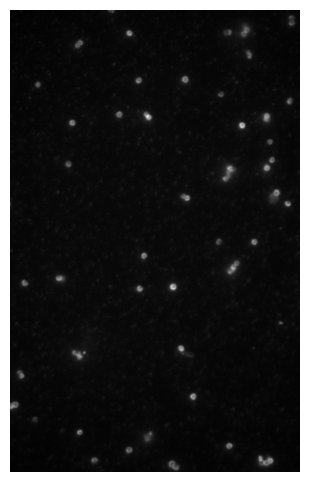

In [65]:
img = image.copy()
print("Selected image shape:", img.shape)
print("Selected image dtype:", img.dtype)
print("Selected image min/max:", img.min(), img.max())

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [66]:
def segment_bright_bacteria(
    image: np.ndarray,
    min_area: int = 3,
    max_area: int = 200,
    sigma_bg: float = 10,
    threshold_scale: float = 0.8
) -> tuple[np.ndarray, np.ndarray]:
    """
    Segment bright fluorescent bacteria using classical image processing.
    """

    image = image.astype(np.float32)

    # Background subtraction
    background = filters.gaussian(image, sigma=sigma_bg)
    corrected = image - background
    corrected[corrected < 0] = 0

    # Normalize to 0-1
    corrected = exposure.rescale_intensity(
        corrected,
        in_range="image",
        out_range=(0, 1)
    )

    # Threshold
    otsu_threshold = filters.threshold_otsu(corrected)
    threshold = otsu_threshold * threshold_scale
    binary = corrected > threshold

    # Clean objects
    binary = morphology.remove_small_objects(binary, min_size=min_area)
    binary = morphology.remove_small_holes(binary, area_threshold=2)

    # Lightly close small gaps
    binary = morphology.binary_closing(binary, morphology.disk(1))

    # Label objects
    labelled = measure.label(binary)

    # Filter by object area
    filtered_mask = np.zeros_like(labelled, dtype=np.uint16)
    new_label = 1

    for region in measure.regionprops(labelled):
        if min_area <= region.area <= max_area:
            filtered_mask[labelled == region.label] = new_label
            new_label += 1

    return filtered_mask, corrected

In [67]:
def filter_mask(mask: np.ndarray, options: dict = {}) -> np.ndarray:
    """
    Filter segmentation mask based on area, length, and width.
    """

    min_area = options.get("min_area", None)
    max_area = options.get("max_area", None)

    min_length = options.get("min_length", None)
    max_length = options.get("max_length", None)

    min_width = options.get("min_width", None)
    max_width = options.get("max_width", None)

    label_mask = np.copy(mask)

    if label_mask.ndim == 2:
        regions = regionprops(label_mask)

        filtered_mask = np.zeros_like(mask)

        for region in regions:
            area = region.area
            length = region.axis_major_length
            width = region.axis_minor_length

            if (
                (min_area is None or area >= min_area)
                and (max_area is None or area <= max_area)
                and (min_length is None or length >= min_length)
                and (max_length is None or length <= max_length)
                and (min_width is None or width >= min_width)
                and (max_width is None or width <= max_width)
            ):
                filtered_mask[label_mask == region.label] = region.label

    elif label_mask.ndim == 3:
        filtered_mask = np.zeros_like(mask)

        for i, current_mask in enumerate(label_mask):
            current_filtered_mask = filter_mask(current_mask, options=options)
            filtered_mask[i] = current_filtered_mask

    else:
        raise ValueError("Mask must be 2D or 3D.")

    return filtered_mask

In [68]:
def preview_results(original, corrected, masks):
    """
    Preview original image, corrected image, mask, and overlay.
    """

    boundaries = find_boundaries(masks, mode="outer")

    mask_display = exposure.rescale_intensity(
        masks.astype(np.float32),
        in_range="image",
        out_range=(0, 1)
    )

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(original, cmap="gray")
    plt.title("Original image")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(corrected, cmap="gray")
    plt.title("Corrected image")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(mask_display, cmap="gray")
    plt.title("Segmentation mask")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(original, cmap="gray")
    plt.contour(boundaries, colors="red", linewidths=0.5)
    plt.title("Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [69]:
def save_overlay(image, masks, output_path):
    """
    Save an overlay image showing segmentation boundaries on the original image.
    """

    boundaries = find_boundaries(masks, mode="outer")

    plt.figure(figsize=(8, 8))
    plt.imshow(image, cmap="gray")
    plt.contour(boundaries, colors="red", linewidths=0.5)
    plt.axis("off")
    plt.savefig(output_path, dpi=300, bbox_inches="tight", pad_inches=0)
    plt.close()

In [70]:
masks, corrected = segment_bright_bacteria(
    img,
    min_area=3,
    max_area=200,
    sigma_bg=10,
    threshold_scale=0.6
)

print(f"Segmentation complete.")
print(f"Masks shape: {masks.shape}")
print("Unique mask values:", np.unique(masks))
print("Number of objects:", len(np.unique(masks)) - 1)

Segmentation complete.
Masks shape: (684, 428)
Unique mask values: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50]
Number of objects: 50


/var/folders/6n/mgwb9sl55vj3wvlx7n_25dzm0000gp/T/ipykernel_36873/2268677000.py:32: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = morphology.remove_small_objects(binary, min_size=min_area)
/var/folders/6n/mgwb9sl55vj3wvlx7n_25dzm0000gp/T/ipykernel_36873/2268677000.py:33: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed 

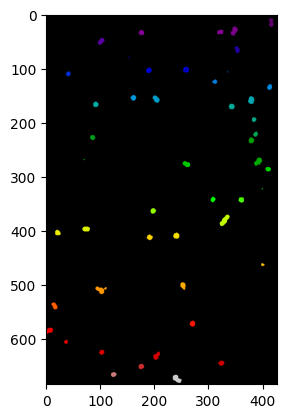

In [71]:
plt.imshow(masks, cmap="nipy_spectral")

In [73]:
import pandas as pd
from skimage.measure import regionprops

measurements = []

regions = regionprops(masks, intensity_image=img)

for region in regions:
    label_id = region.label

    area = region.area

    y, x = region.centroid

    y_min, x_min, y_max, x_max = region.bbox

    major_length = region.axis_major_length
    minor_length = region.axis_minor_length
    eccentricity = region.eccentricity
    solidity = region.solidity

    mean_intensity = region.mean_intensity
    max_intensity = region.max_intensity

    measurements.append({
        "label": label_id,
        "area": area,
        "x": x,
        "y": y,
        "x_min": x_min,
        "y_min": y_min,
        "x_max": x_max,
        "y_max": y_max,
        "major_length": major_length,
        "minor_length": minor_length,
        "eccentricity": eccentricity,
        "solidity": solidity,
        "mean_intensity": mean_intensity,
        "max_intensity": max_intensity,
    })

df_measure = pd.DataFrame(measurements)

df_measure.head()

print(df_measure)

    label   area           x           y  x_min  y_min  x_max  y_max  \
0       1   28.0  149.464286    1.142857    145      0    154      4   
1       2  110.0  415.045455   15.454545    411      8    420     24   
2       3  144.0  346.770833   30.951389    341     23    354     40   
3       4   79.0  175.708861   34.025316    171     29    181     39   
4       5   81.0  321.111111   32.888889    316     29    327     38   
5       6  106.0  101.273585   49.952830     96     44    108     57   
6       7   84.0  352.297619   65.404762    348     59    358     72   
7       8    6.0  153.166667   79.833333    152     79    155     82   
8       9   97.0  258.000000  102.422680    253     97    264    109   
9      10   78.0  189.423077  103.705128    185     99    195    109   
10     11   59.0   40.762712  110.101695     37    106     46    115   
11     12    4.0  334.500000  106.500000    334    106    336    108   
12     13   55.0  311.054545  124.672727    306    121    316   

/var/folders/6n/mgwb9sl55vj3wvlx7n_25dzm0000gp/T/ipykernel_36873/2454664336.py:22: FutureWarning: `RegionProperties.mean_intensity` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.intensity_mean` instead. 
  mean_intensity = region.mean_intensity
/var/folders/6n/mgwb9sl55vj3wvlx7n_25dzm0000gp/T/ipykernel_36873/2454664336.py:23: FutureWarning: `RegionProperties.max_intensity` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.intensity_max` instead. 
  max_intensity = region.max_intensity


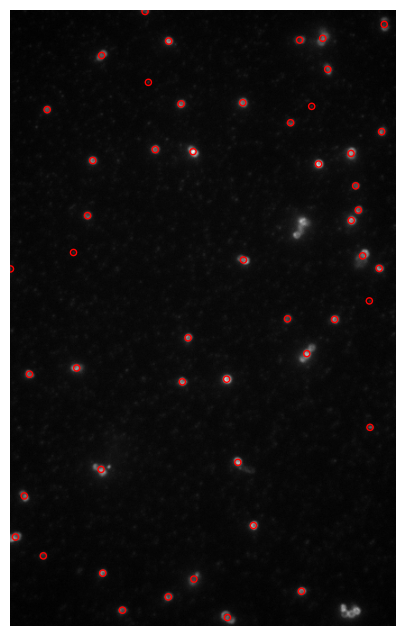

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.imshow(img, cmap="gray")

plt.scatter(
    df_measure["x"],
    df_measure["y"],
    s=20,
    facecolors="none",
    edgecolors="red",
    linewidths=1
)

plt.axis("off")
plt.show()

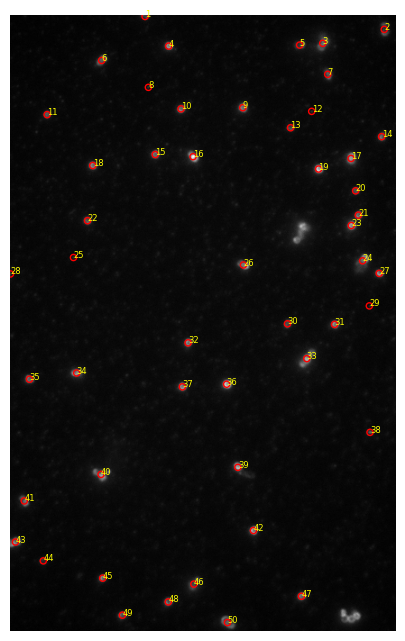

In [75]:
plt.figure(figsize=(8, 8))
plt.imshow(img, cmap="gray")

plt.scatter(
    df_measure["x"],
    df_measure["y"],
    s=20,
    facecolors="none",
    edgecolors="red"
)

for _, row in df_measure.iterrows():
    plt.text(
        row["x"],
        row["y"],
        str(int(row["label"])),
        color="yellow",
        fontsize=6
    )

plt.axis("off")
plt.show()

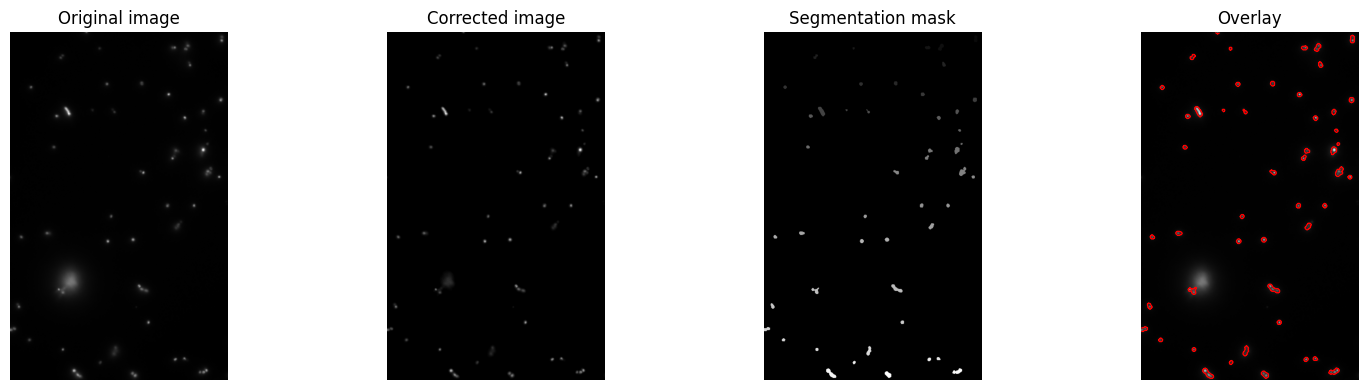

In [55]:
preview_results(img, corrected, masks)